## Installation et import des libraries

In [ ]:
%pip install matplotlib 
%pip install numpy --quiet
%pip install tensorflow --quiet
%pip install tabulate --quiet
%pip install scikit-learn --quiet
%pip install seaborn --quiet


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib
from tabulate import tabulate

I0000 00:00:1779870984.628131    9113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779870984.957314    9113 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779870986.637849    9113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Constantes

In [ ]:
DATA_DIR = pathlib.Path("../../datasets/livrable1")
IMAGE_HEIGHT = 180
IMAGE_WIDTH = 180
BATCH_SIZE = 16
NB_EPOCHS = 20
SEED = 123

# Reproductibilité
import random
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

## Traitement

### Suppression des images corrompues

Certaines images du dataset sont corrompues et ne peuvent pas être lues par les fonctions de traitement d'images ce qui génère une erreur lors de l'exécution du code et bloque l'entraînement.
Il est donc nécessaire de supprimer ces images.

In [4]:
# Suppression des images corrompues
num_skipped = 0

for image in DATA_DIR.glob("*/*.*"):
    try:
        img = PIL.Image.open(image)
        img.verify()

        img_bytes = tf.io.read_file(str(image))
        decoded_img = tf.io.decode_image(img_bytes)
    except (IOError, SyntaxError, tf.errors.InvalidArgumentError) as e:
        print("Suppression de l'image corrompue : ", image)
        num_skipped += 1
        image.unlink()

print(f"Nombre d'images corrompues supprimées : {num_skipped}")

W0000 00:00:1779871053.472338    9113 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9
W0000 00:00:1779871096.873886    9113 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


Nombre d'images corrompues supprimées : 0


### Conversion des PNG en JPEG

In [5]:
# Conversion des PNG en JPEG
for image in DATA_DIR.glob("*/*.png"):
    try:
        img = PIL.Image.open(image)
        rgb_img = img.convert("RGB")
        new_image_path = image.with_suffix(".jpg")
        rgb_img.save(new_image_path, "JPEG")
        image.unlink()
    except (IOError, SyntaxError) as e:
        print("Erreur lors de la conversion de l'image : ", image)

## Pré-analyse

In [6]:
print("Nombre d'image : ", len(list(DATA_DIR.glob("*/*.jpg"))))

Nombre d'image :  41398


Afficher le nombre d'image pour chaque classe (sous-dossier) dans le dataset afin de vérifier que l'entraînement ne sera pas biaisé par un déséquilibre entre les classes.

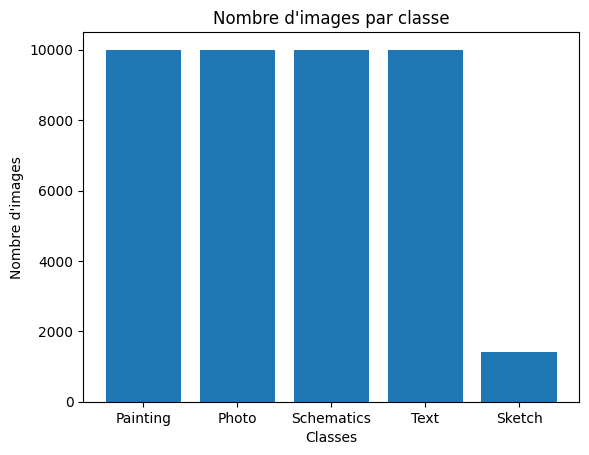

In [7]:
categories = {}

for cat in DATA_DIR.iterdir():
    if cat.is_dir():
        categories[cat.name] = len(list(cat.glob("*.*")))

plt.bar(categories.keys(), categories.values())
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")
plt.title("Nombre d'images par classe")
plt.show()

## Entraînement du modèle

### Création du dataset d'entraînement et de validation

Création de deux datasets. Un d'entraînement qui contient 80% des images étant utilisées pour entraîner le modèle. Le second dataset, de validation, contient les 20% d'images restantes et est utilisé pour évaluer les performances du modèle pendant l'entraînement.

In [8]:
# Le train_set et validation
[train_set, test_set] = tf.keras.preprocessing.image_dataset_from_directory(
  DATA_DIR,
  labels='inferred',
  validation_split=0.2,
  subset ="both",
  seed=SEED,
  image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
  batch_size=BATCH_SIZE
)

Found 41398 files belonging to 5 classes.
Using 33119 files for training.
Using 8279 files for validation.


### Visualisation des données

In [9]:
class_names = train_set.class_names
print(class_names)

['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']


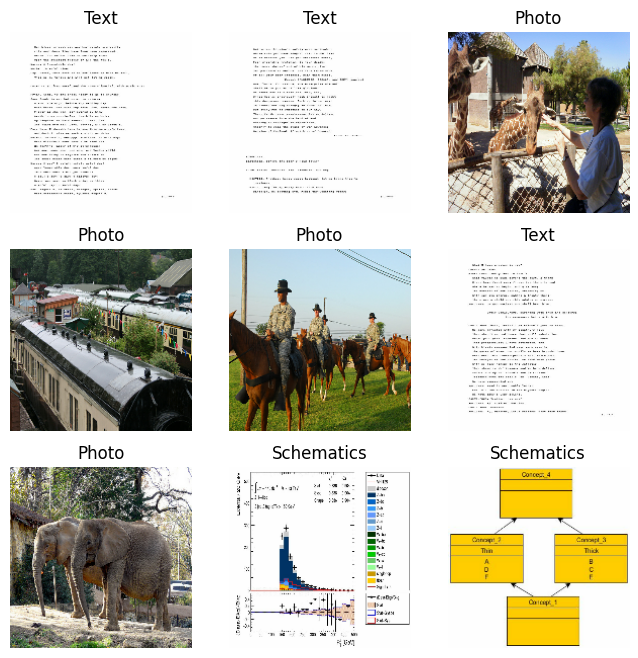

In [10]:
plt.figure(figsize=(8, 8))
for images, labels in train_set.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [11]:
images, labels =  train_set.as_numpy_iterator().next()
print(images.shape)
print(labels.shape)

(16, 180, 180, 3)
(16,)


### Définition des hyperparamètres pour améliorer les performances du modèle

In [12]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

# Garder les images en mémoire afin de ne pas relire les images à chaque epoch (cache).
# Prétraiter les données pendant que le modèle s'entraîne (prefetch).
train_set = train_set.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_set = test_set.cache().prefetch(buffer_size=AUTOTUNE)

### Récupération du nombre de classes

In [13]:
# Nombre de classes = nombre de neurones de la couche de sortie du modèle
nombre_classes = len(class_names)

### Création du modèle

In [14]:
# Création du model
model = Sequential([
    layers.Rescaling(1./255, input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(nombre_classes, activation='softmax')
])

/home/tt/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### Fonctions d'activation

##### Relu

##### Softmax

### Compilation du model

In [15]:
# Compilation du model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

### Entraînement du model

In [16]:
# Entraînement du model
history = model.fit(
    train_set,
    validation_data=test_set,
    epochs=NB_EPOCHS
)

Epoch 1/20


/home/tt/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:1216: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


 100/2070 ━━━━━━━━━━━━━━━━━━━━ 1:53 57ms/step - accuracy: 0.4731 - loss: 1.4160

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


2070/2070 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7391 - loss: 0.6314

W0000 00:00:1779871324.218369   14664 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


2070/2070 ━━━━━━━━━━━━━━━━━━━━ 120s 54ms/step - accuracy: 0.8043 - loss: 0.4748 - val_accuracy: 0.8468 - val_loss: 0.3783
Epoch 2/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 114s 55ms/step - accuracy: 0.8857 - loss: 0.2886 - val_accuracy: 0.8907 - val_loss: 0.2782
Epoch 3/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 113s 54ms/step - accuracy: 0.9193 - loss: 0.2078 - val_accuracy: 0.8902 - val_loss: 0.2968
Epoch 4/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 113s 55ms/step - accuracy: 0.9481 - loss: 0.1394 - val_accuracy: 0.8937 - val_loss: 0.3408
Epoch 5/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 113s 55ms/step - accuracy: 0.9659 - loss: 0.0950 - val_accuracy: 0.8710 - val_loss: 0.4712
Epoch 6/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 113s 55ms/step - accuracy: 0.9769 - loss: 0.0690 - val_accuracy: 0.9045 - val_loss: 0.3425
Epoch 7/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 101s 49ms/step - accuracy: 0.9836 - loss: 0.0491 - val_accuracy: 0.8938 - val_loss: 0.4910
Epoch 8/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 101s 49ms/step - accuracy: 0.9866 - lo

### Performances du modèle

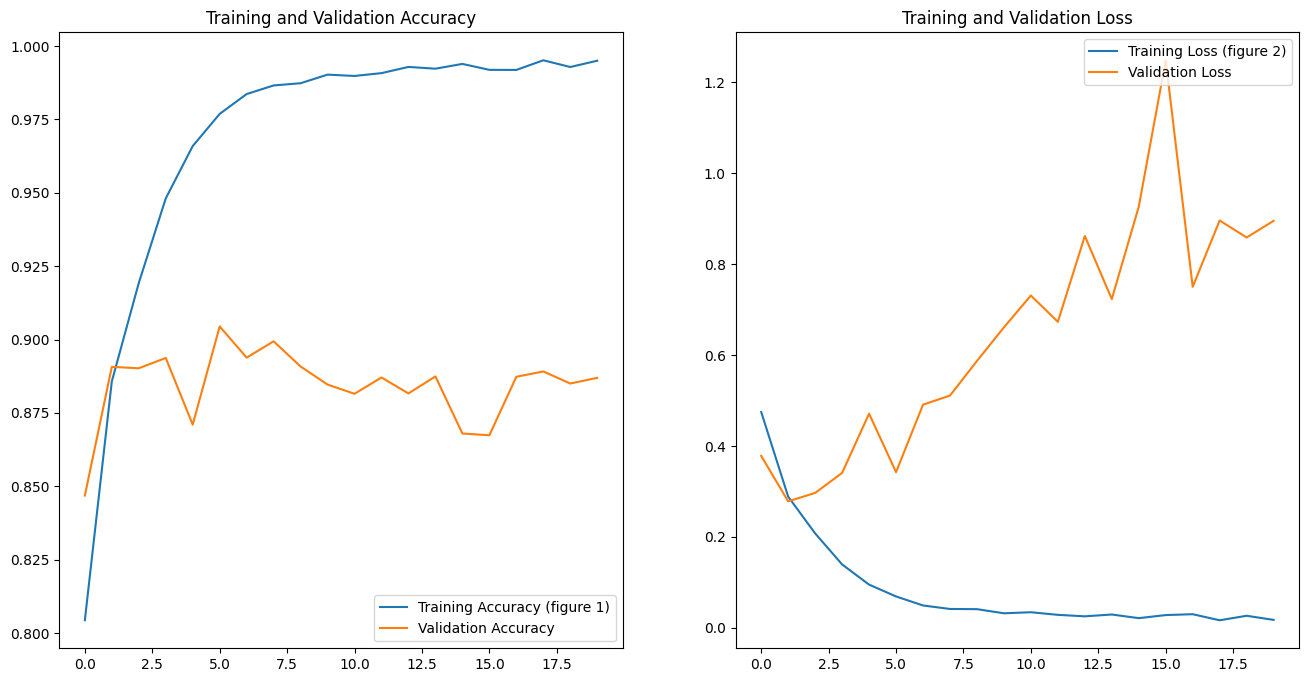

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(NB_EPOCHS)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy (figure 1)')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss (figure 2)')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Sauvegarde du modèle

In [18]:
model.save('../../models/livrable1/model.keras')

### Interprétation des résultats

La figure 1 montre une accuracy d'entraînement qui augmente régulièrement (vers 100%) tandis que la validation peine à suivre, symptomatique d'un **surapprentissage (overfitting)**. Le modèle "mémorise" les données, aidé par sa grande capacité (ex: `Dense(128)`). Pour contrer cela, la **version améliorée** du modèle intègre plusieurs leviers de régularisation :

1. **Data Augmentation** : Enrichit artificiellement le jeu d'entraînement (rotations, zooms) pour forcer l'invariance.
2. **Dropout** : Désactive aléatoirement des neurones pour éviter la co-adaptation et forcer un apprentissage distribué.
3. **Régularisation (L1/L2)** : Pénalise les poids trop élevés pour restreindre la complexité.
4. **Early Stopping** : Interrompt l'entraînement dès que la perte de validation remonte, en restaurant les meilleurs poids.

## Amélioration du modèle

### Dropout
La technique du **Dropout** agit comme une méthode de régularisation intégrée au réseau. Lors de l'entraînement, une fraction aléatoire des neurones (par exemple 20% ou 50%) est désactivée à chaque itération. Cela empêche le réseau de reposer excessivement sur quelques connexions fortes (co-adaptation). Il est ainsi obligé d'apprendre des caractéristiques de manière distribuée et redondante, ce qui le rend nettement plus robuste face au surapprentissage.

### Data augmentation
L'**augmentation de données** est cruciale lorsque la taille du dataset est limitée. On applique à la volée des transformations artificielles – mais plausibles – aux images d'entraînement (basculements horizontaux, petites rotations, zooms aléatoires). Ainsi, le modèle ne voit quasiment jamais la même image exacte à chaque itération : il est forcé d'apprendre des concepts invariants (la forme intrinsèque de l'objet) et non des éléments spécifiques à une vue donnée, ce qui décuple sa capacité de généralisation.

### Learning rate

Le taux d'apprentissage (**learning rate**) détermine l'amplitude de la mise à jour des poids lors de la descente de gradient. C'est l'hyperparamètre le plus impactant :
* **S'il est trop élevé** : La descente de gradient fait un pas trop grand, ce qui peut faire diverger l'apprentissage ou rendre la `validation loss` très instable (incapacité à s'arrêter au niveau du minimum).
* **S'il est trop faible** : L'apprentissage est beaucoup plus lent. De plus, le modèle a le risque de rester bloqué ou de converger seulement vers un minimum local sous-optimal.

#### Valeur initiale
Le choix du pas de départ est important. Généralement, on définit une valeur initiale standard (par exemple `0.001` avec l'optimiseur Adam) qui permet de parcourir rapidement la fonction de coût lors des premières époques et de trouver une bonne zone générale pour les poids du réseau.

#### Learning rate scheduler
Parfois, le réseau atteint un "plateau" où la perte ne diminue plus : on tourne autour du minimum sans réussir à y descendre. Un *Scheduler* (comme `ReduceLROnPlateau`) surveille la performance (par exemple la `val_loss`) et réduit dynamiquement le learning rate (ex: division par 2) lorsque celle-ci stagne pendant quelques epochs. Cela permet d'affiner la précision des poids en fin d'entraînement.

### Early stopping
L'**Arrêt Anticipé** (*Early Stopping*) est une méthode de surveillance des performances. Dès que l'on observe que la perte de validation commence à se dégrader (remonter) de manière répétée au fil des époques (définies par une valeur de tolérance `patience`), l'entraînement est stoppé. Le grand bénéfice est qu'il permet de récupérer et sauvegarder automatiquement les poids du modèle à son pic optimal de performance, avant que le surapprentissage ne l'ait détérioré.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 578s 278ms/step - accuracy: 0.6862 - loss: 0.7636 - val_accuracy: 0.7154 - val_loss: 0.7750 - learning_rate: 1.0000e-04
Epoch 2/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 575s 278ms/step - accuracy: 0.7692 - loss: 0.5585 - val_accuracy: 0.6581 - val_loss: 1.0839 - learning_rate: 1.0000e-04
Epoch 3/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 510s 246ms/step - accuracy: 0.8066 - loss: 0.4792 - val_accuracy: 0.6977 - val_loss: 0.7959 - learning_rate: 1.0000e-04
Epoch 4/20
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 495s 239ms/step - accuracy: 0.8361 - loss: 0.4120 - val_accuracy: 0.7025 - val_loss: 0.9427 - learning_rate: 5.0000e-05


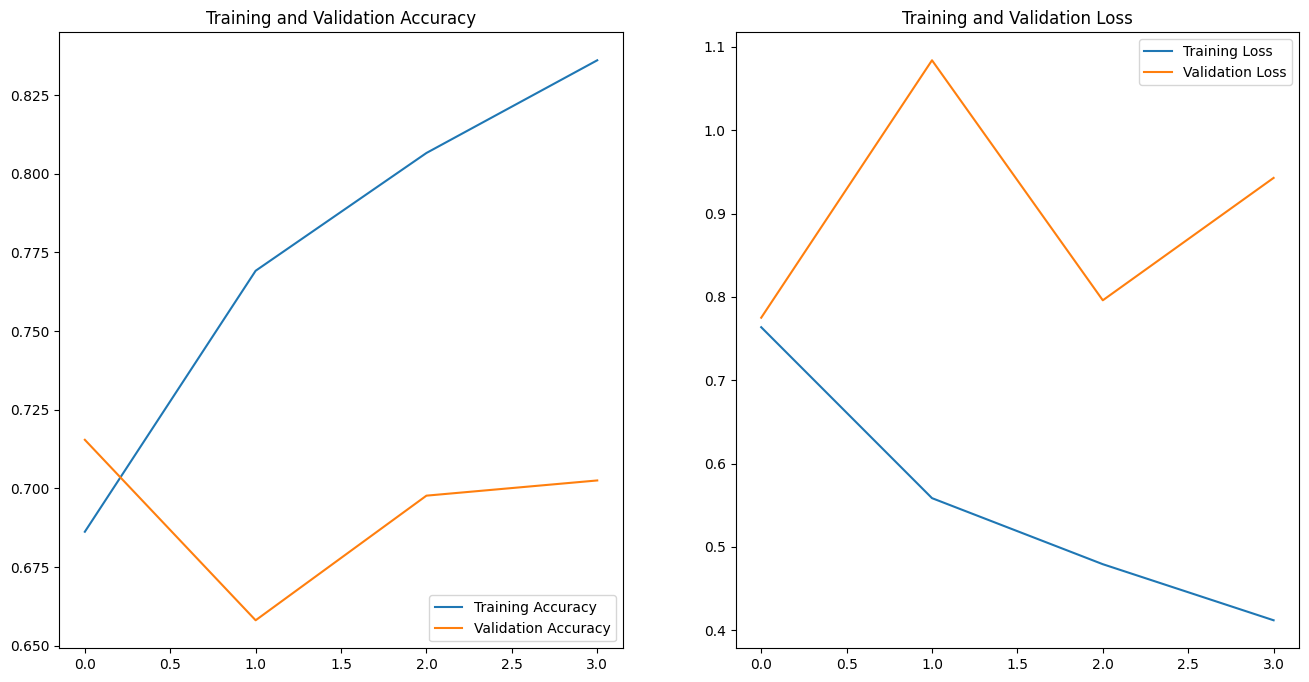

In [ ]:
# Early stopping
# Si aucune amélioration n'est constatée au bout de 3 epochs, on arrête l'entraînement et on restaure les poids du meilleur modèle.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Learning rate scheduler
learning_rate_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# ModelCheckpoint pour sauvegarder les meilleurs poids
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '../../models/livrable1/improved_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Création du model amélioré
improved_model = Sequential([
    # Augmentation du jeu de données
    layers.RandomFlip("horizontal", input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),
    layers.RandomRotation(0.18),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.Rescaling(1. / 255),

    # Extraction des caractéristiques
    layers.Conv2D(16, 3, padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Réduction de la dimension pour limiter l'overfitting
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(nombre_classes, activation='softmax'),
    
])

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# Compilation du model
improved_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

improved_model.summary()

# Entraînement du model
history_imp_model = improved_model.fit(
    train_set,
    validation_data=test_set,
    epochs=NB_EPOCHS,
    callbacks=[early_stopping, learning_rate_scheduler]
 )

acc = history_imp_model.history['accuracy']
val_acc = history_imp_model.history['val_accuracy']

loss = history_imp_model.history['loss']
val_loss = history_imp_model.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Évaluation détaillée: matrice de confusion et rapport de classification

from sklearn.metrics import confusion_matrix, classification_report

# Collecter vraies étiquettes et prédictions sur l'ensemble de validation/test
y_true = []
y_pred = []
for images, labels in test_set:
    preds = improved_model.predict(images)
    preds = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
print(classification_report(y_true, y_pred, target_names=class_names))

# Affichage de la matrice de confusion
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()

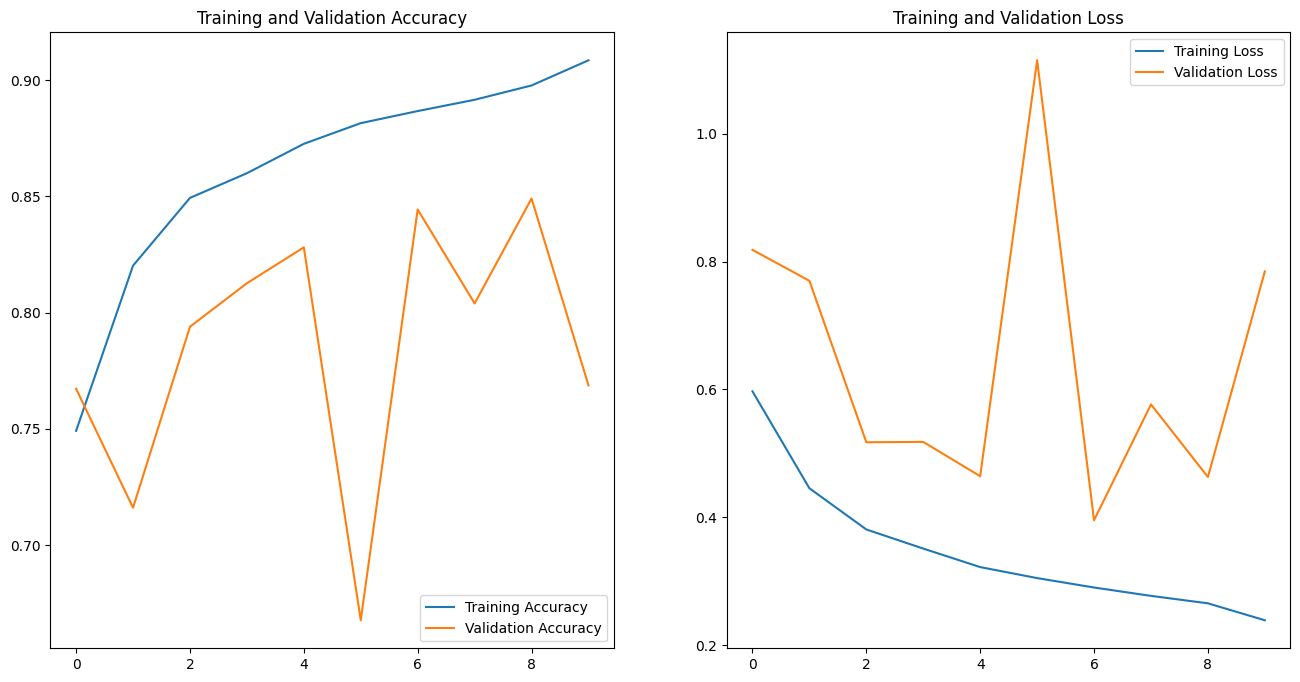

In [20]:
acc = history_imp_model.history['accuracy']
val_acc = history_imp_model.history['val_accuracy']

loss = history_imp_model.history['loss']
val_loss = history_imp_model.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Sauvegarde du modèle amélioré

In [21]:
improved_model.save('../../models/livrable1/improved_model.keras')

## Prédiction sur une image de test

In [29]:
improved_model = keras.models.load_model('../../models/livrable1/improved_model.keras', compile=False)

random_image = np.random.choice(list(DATA_DIR.glob("*/*.jpg")))
class_image = random_image.parent.name

# random_image = "../../datasets/test/imagesTest/9.jpg"


img = keras.preprocessing.image.load_img(
    random_image, target_size=(IMAGE_HEIGHT, IMAGE_WIDTH)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)


predictions = improved_model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


### Affichage de l'image de test

(np.float64(-0.5), np.float64(179.5), np.float64(179.5), np.float64(-0.5))

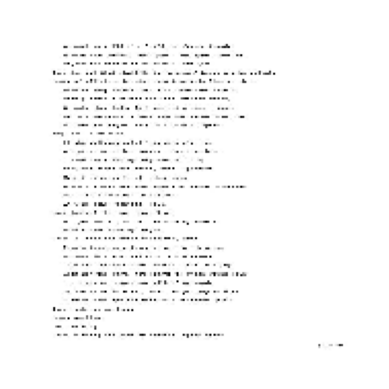

In [30]:
plt.imshow(img)
plt.axis("off")

### Affichage des résultats

In [31]:
score = predictions[0]

print("Cette image est probablement un {} avec une confiance de {:.2f}%.".format(
    class_names[np.argmax(score)], 100 * np.max(score),
))

res = [
    {"Classe": class_names[i], "Confiance (%)": 100 * score[i]}
    for i in range(len(class_names))
]

print(tabulate([[r["Classe"], r["Confiance (%)"]] for r in res], headers=["Classe", "Confiance (%)"]))

Cette image est probablement un Text avec une confiance de 40.34%.
Classe        Confiance (%)
----------  ---------------
Painting            14.9005
Photo               14.9004
Schematics          14.9453
Sketch              14.9168
Text                40.337


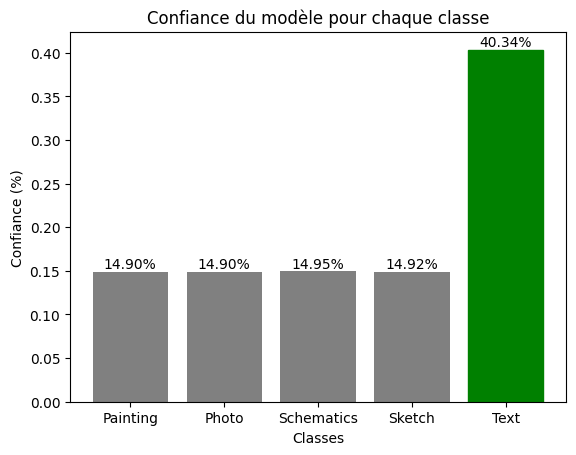

In [32]:
predicted_label = class_names[np.argmax(score)]

bar_plot = plt.bar(class_names, score.numpy(), color='gray')
plt.bar_label(bar_plot, ["{:.2f}%".format(100 * s) for s in score.numpy()])
# Colorier en rouge la barre correspondant à la classe prédite et en vert la barre correspondant à la classe réelle de l'image
bar_plot[np.argmax(score)].set_color('red')
bar_plot[[i for i in range(len(class_names)) if class_names[i] == class_image][0]].set_color('green')
plt.xlabel("Classes")
plt.ylabel("Confiance (%)")
plt.title("Confiance du modèle pour chaque classe")
plt.show()

### Feature map

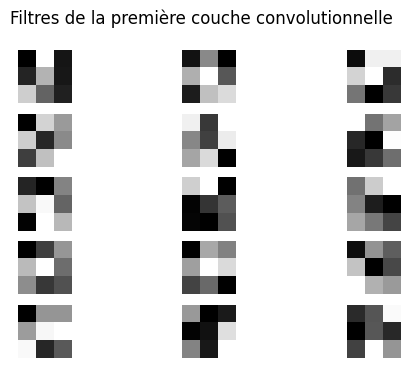

In [33]:
for layer in improved_model.layers:
    if 'conv' not in layer.name:
        continue

    first_layer = layer

    # Récupération des poids de la première couche convolutionnelle
    filters, biais = layer.get_weights()

    # Normalisation des filtres pour les visualiser
    f_min, f_max = filters.min(), filters.max()
    filters = (filters - f_min) / (f_max - f_min)

    # Visualisation des 5 premiers filtres de la première couche convolutionnelle
    n_filters = 5
    n_columns = 3
    ix = 1
    n_rows = n_filters // n_columns + (n_filters % n_columns > 0)
    plt.figure(figsize=(n_columns * 2, n_rows * 2))

    for i in range(n_filters):
        f = filters[:, :, :, i]

        for j in range(3):
            ax = plt.subplot(n_filters, 3, ix)
            plt.imshow(f[:, :, j], cmap='gray')
            plt.axis("off")
            ix += 1

    plt.suptitle("Filtres de la première couche convolutionnelle")
    plt.show()

    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Shape of the feature map:  (1, 180, 180, 16)


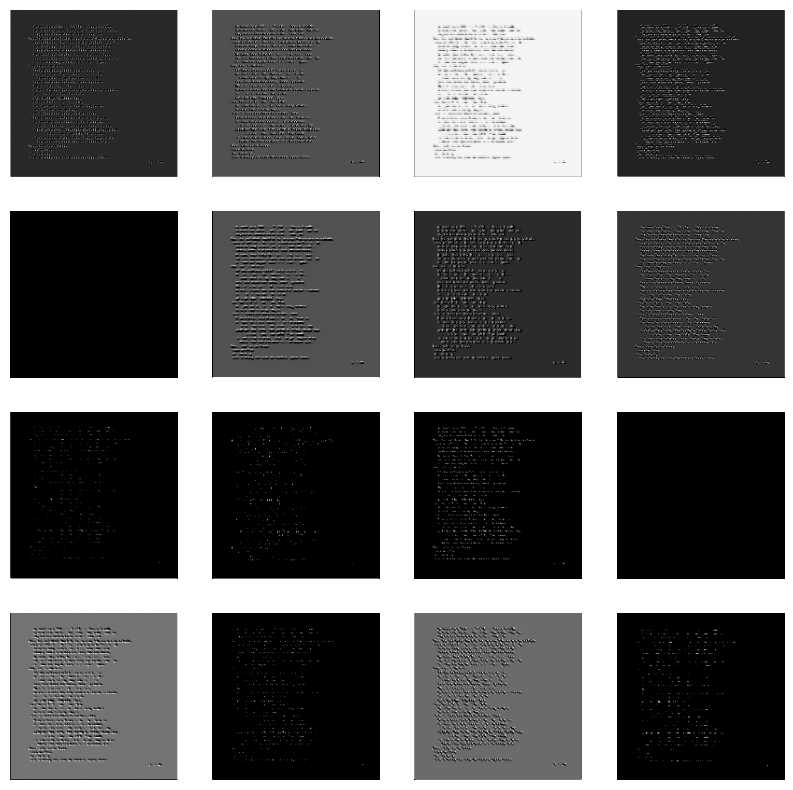

In [34]:
model = keras.models.Model(inputs=improved_model.inputs, outputs=first_layer.output)

feature = model.predict(img_array)
print("Shape of the feature map: ", feature.shape)

fig = plt.figure(figsize=(10, 10))
for i in range(feature.shape[-1]):
    ax = fig.add_subplot(4, 4, i + 1)
    plt.imshow(feature[0, :, :, i], cmap='gray')
    plt.axis("off")

 en général c’est une bonne chose si les courbes d’entraînement et de validation se superposent : cela signifie que le modèle généralise bien (peu ou pas de surapprentissage).

Nuances courtes :

Si les deux courbes montrent haute accuracy / faible loss → excellent signe.
Si les deux sont basses/stagnantes → sous-apprentissage (modèle trop simple ou besoin d’entraînement/données).
Si la courbe d’entraînement est bien meilleure que la validation (divergence) → surapprentissage.
Actions possibles si ça diverge : augmenter la régularisation (L2, Dropout), ajouter de l’augmentation de données, utiliser early stopping, ou collecter plus de données.